In [1]:
using Oceananigans
using JLD2
using CairoMakie
using CairoMakie.Colors
using Statistics

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

include("../src-fig/plotting.jl")
include("../setup/ensemble.jl")

run_ids = cooling_only.filenames

[ Info: Oceananigans will use 4 threads


16-element Vector{String}:
 "0_1-0_1-0_01-0_0-C"
 "0_1-0_1-0_02-0_0-C"
 "0_1-0_1-0_03-0_0-C"
 "0_1-0_1-0_04-0_0-C"
 "0_1-0_1-0_05-0_0-C"
 "0_1-0_1-0_06-0_0-C"
 "0_1-0_1-0_07-0_0-C"
 "0_1-0_1-0_08-0_0-C"
 "0_1-0_1-0_09-0_0-C"
 "0_1-0_1-0_1-0_0-C"
 "0_1-0_1-0_11-0_0-C"
 "0_1-0_1-0_12-0_0-C"
 "0_1-0_1-0_13-0_0-C"
 "0_1-0_1-0_14-0_0-C"
 "0_1-0_1-0_15-0_0-C"
 "0_1-0_1-0_2-0_0-C"

In [8]:
ψs = map(run_ids) do run_id
    DFM = joinpath("../../scratch/turbulence-at-many-fronts", run_id, "DFM.jld2")
    iterations, times = iterations_times(DFM)
    sp = simulation_parameters(DFM)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
    data = timeseries_of(DFM, "ψ_dfm", iterations) do field
        mean(field)
    end
end;
sps = map(run_ids) do run_id
    DFM = joinpath("../../scratch/turbulence-at-many-fronts", run_id, "DFM.jld2")
    iterations, times = iterations_times(DFM)
    sp = simulation_parameters(DFM)
end;

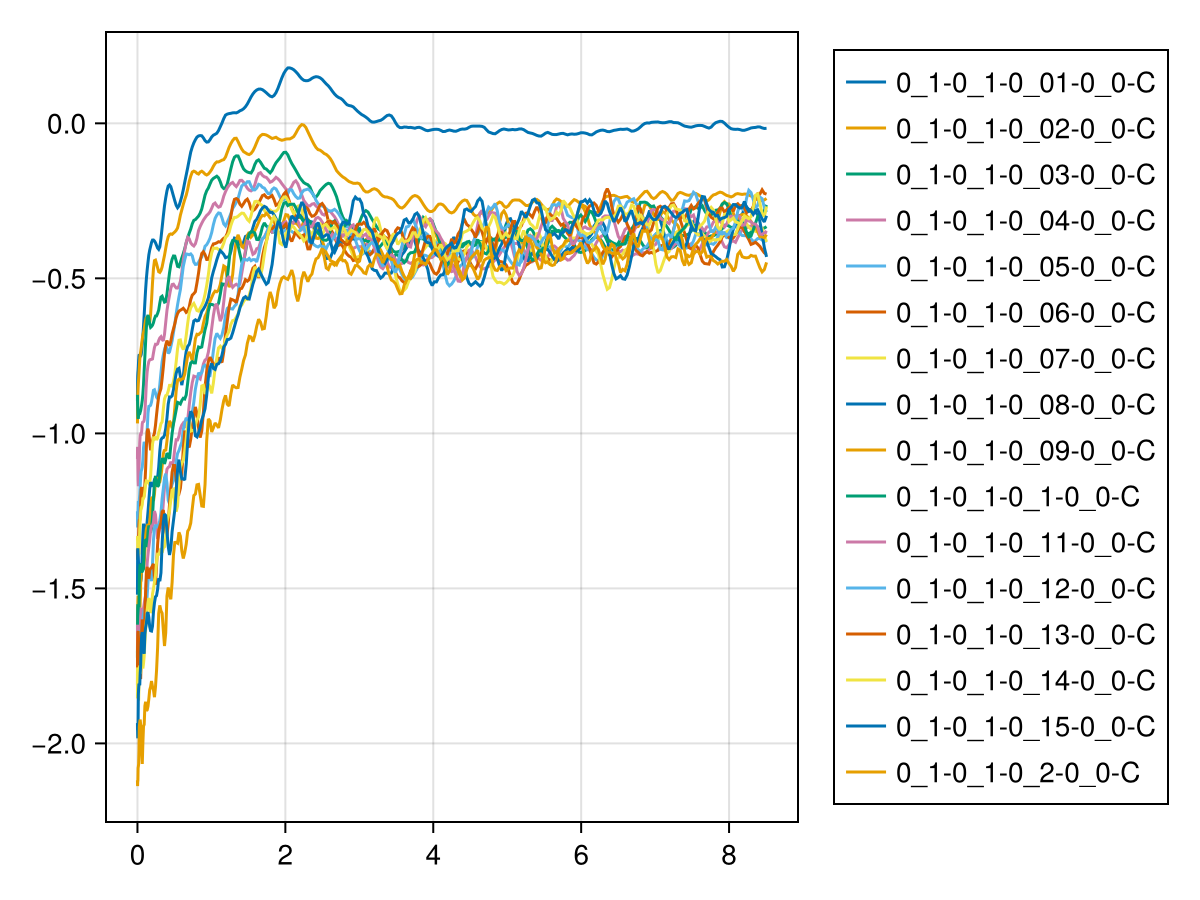

In [6]:
fig = Figure()
ax = Axis(fig[1, 1])
is = 1:16
lns = map(is) do i
    DFM = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i], "DFM.jld2")
    iterations, times = iterations_times(DFM)
    sp = simulation_parameters(DFM)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
    s = normalized_time(DFM)
    inds = center_indices(DFM)
    data = ψs[i] / sqrt(sp.βB)
    lines!(ax, s, log.(abs.(data)))
end
#lines!(ax, 0:2, x->x-3.5)
Legend(fig[1, 2], lns, run_ids[is])
fig

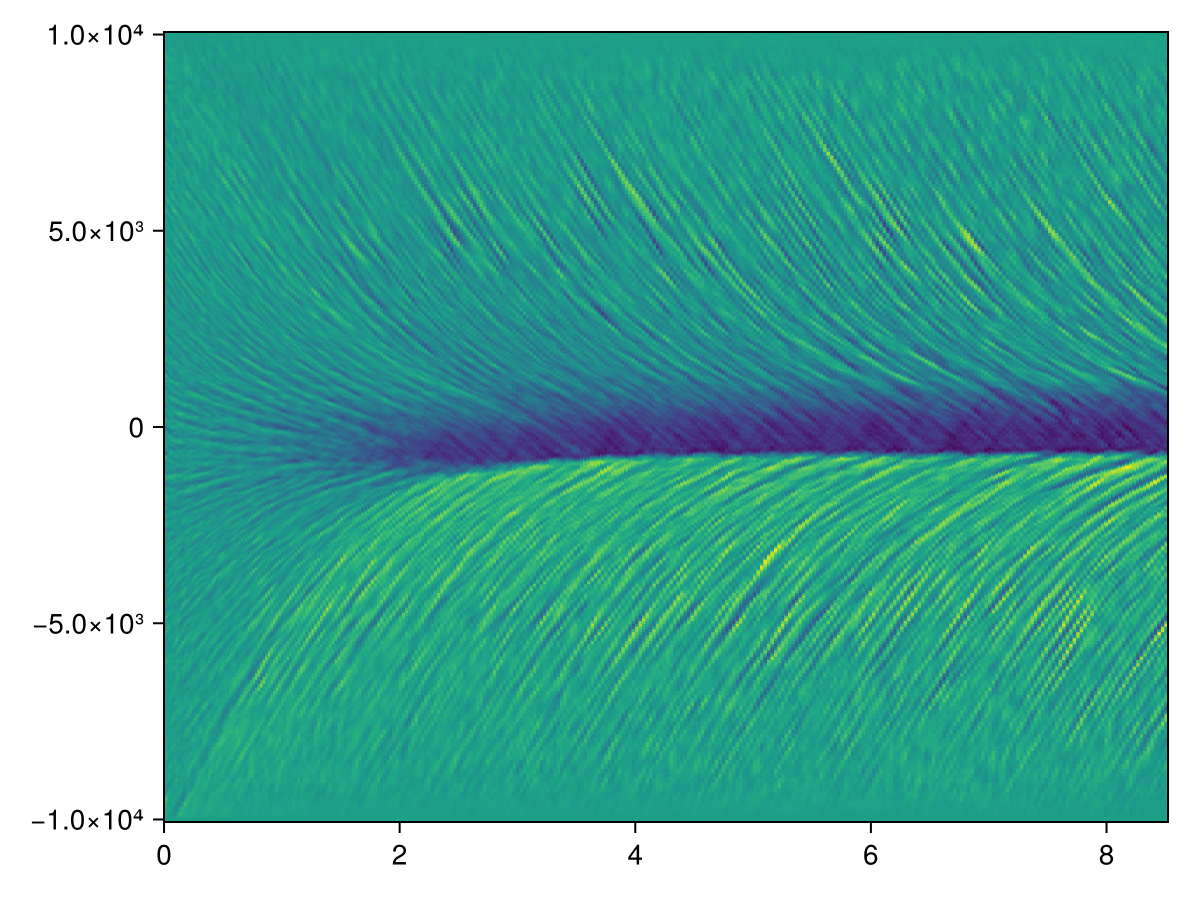

In [56]:
i = 10

fig = Figure()
ax = Axis(fig[1, 1])

DFM = joinpath("../../scratch/turbulence-at-many-fronts", run_ids[i], "DFM.jld2")
iterations, times = iterations_times(DFM)
sp = simulation_parameters(DFM)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
s = normalized_time(DFM)
inds = center_indices(DFM)
data = timeseries_of(DFM, "ψ_dfm", iterations) do field
    mean(field; dims=2)[:, 1]
end
heatmap!(ax, s, xsᶠ, data)

fig

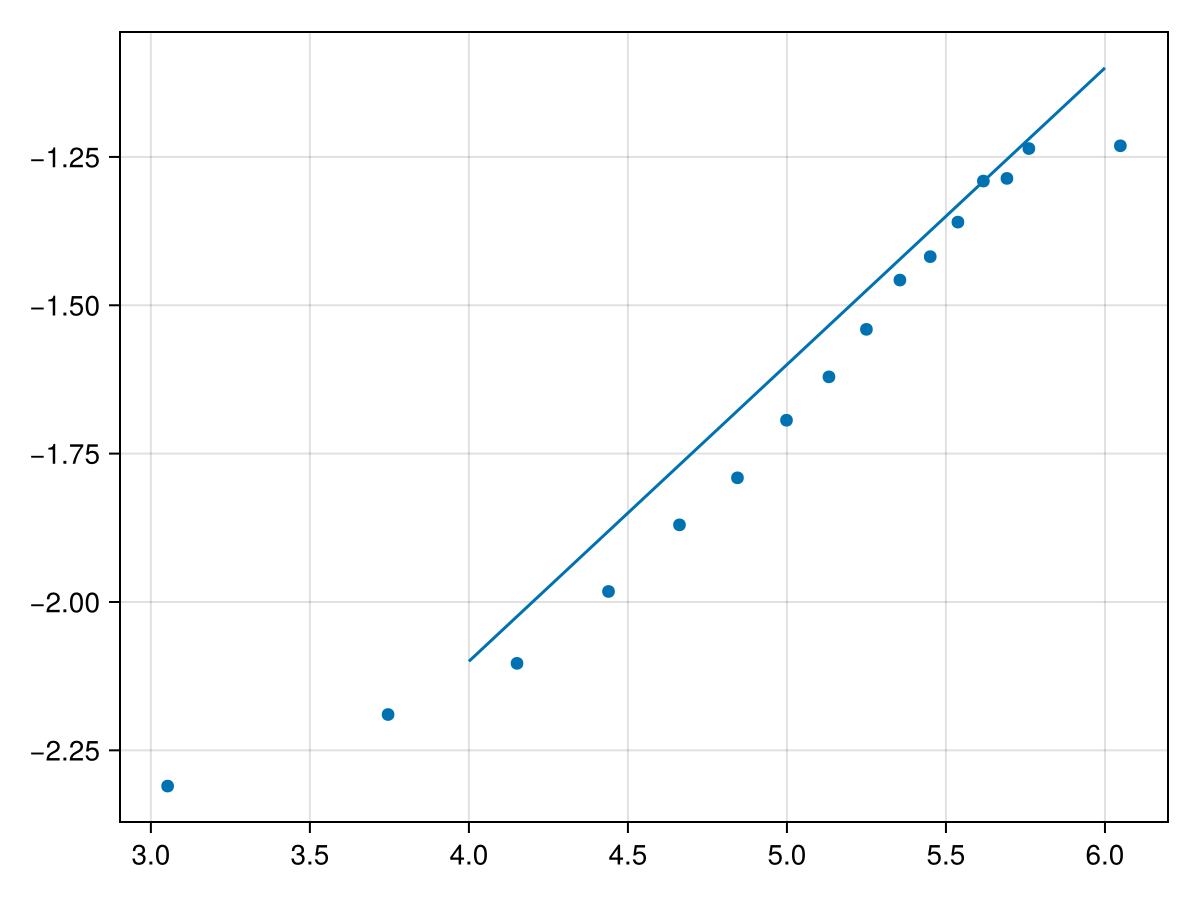

In [26]:
Qs = [sp.Q for sp in sps]
fig = Figure()
ax = Axis(fig[1, 1])
scatter!(ax, log.(Qs), [log(abs(mean(a[end-50:end]))) for a in ψs])
lines!(ax, 4:6, x->0.5(x-4) - 2.1)
fig